# Single-cell spatial gene expression generation

This notebook demonstrates the Step 1 PhenoMap workflow on the HBC1 dataset:

1. extract histology features from the H&E image and cell mask;
2. train the weakly supervised expression-generation model;
3. predict cell-scale gene expression;
4. evaluate prediction accuracy against matched Xenium ground truth with PCC and RMSE;
5. visualize marker genes at spot level, ground-truth single-cell level and predicted single-cell level.

Expensive artifacts are handled automatically: valid caches are reused, and only missing features, model artifacts or predictions are regenerated. Metric and visualization sections rerun normally.


In [1]:
from pathlib import Path
import subprocess
import sys
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import yaml


def find_repo_root():
    current = Path.cwd().resolve()
    for path in (current, *current.parents):
        if (path / "README.md").exists() and (path / "step1").exists():
            return path
    raise RuntimeError("Please run this notebook from inside the PhenoMap repository.")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from phenomap import load_tutorial_data
from step1.utils.metrics import compute_gene_expression_metrics
from step1.utils.plotting import plot_marker_gene_reconstruction, set_plot_style

set_plot_style()
tutorial_data = load_tutorial_data(repository_root=REPO_ROOT)

FEATURE_PATH = tutorial_data.path("hbc1.cell_features")
MEASURED_EXPRESSION = tutorial_data.path("hbc1.measured_expression")
GENERATED_EXPRESSION = tutorial_data.path("hbc1.generated_expression")
CHECKPOINT_PATH = tutorial_data.path("hbc1.step1_checkpoint")
CONFIG_TEMPLATE = REPO_ROOT / "step1" / "configs" / "default.yaml"
TUTORIAL_DIR = REPO_ROOT / "outputs" / "01_single_cell_expression_generation"
TUTORIAL_DIR.mkdir(parents=True, exist_ok=True)
RUNTIME_CONFIG = TUTORIAL_DIR / "step1_runtime.yaml"
MARKER_GENES = ["EPCAM", "CXCL12"]

print("PhenoMap repository and tutorial data manifest configured.")


PhenoMap repository and tutorial data manifest configured.


## 1. Configure the HBC1 Step 1 workflow

The public defaults are defined in `step1/configs/default.yaml`. Dataset-specific resources are supplied by the tutorial data manifest, and a runtime configuration is assembled without exposing local paths.


In [2]:
with CONFIG_TEMPLATE.open("r", encoding="utf-8") as handle:
    config = yaml.safe_load(handle)

config["extract"].update({
    "mask_path": str(tutorial_data.path("hbc1.nucleus_mask")),
    "image_path": str(tutorial_data.path("hbc1.he_image")),
    "output_path": str(FEATURE_PATH),
})
config["data"].update({
    "h5_feature_path": str(FEATURE_PATH),
    "spot_gene_csv": str(tutorial_data.path("hbc1.pseudo_spots")),
    "spot_coord_csv": str(tutorial_data.path("hbc1.spot_locations")),
    "spot_diameter_txt": str(tutorial_data.path("hbc1.spot_diameter")),
    "gene_list_txt": str(tutorial_data.path("hbc1.gene_list")),
    "output_dir": str(CHECKPOINT_PATH.parent),
})
config["predict"].update({
    "h5_path": str(FEATURE_PATH),
    "train_dir": str(CHECKPOINT_PATH.parent),
    "checkpoint": CHECKPOINT_PATH.name,
    "output_csv": str(GENERATED_EXPRESSION),
})
RUNTIME_CONFIG.write_text(yaml.safe_dump(config, sort_keys=False), encoding="utf-8")

pd.DataFrame([
    {"stage": "feature extraction", "cache_available": FEATURE_PATH.exists()},
    {"stage": "model training", "cache_available": CHECKPOINT_PATH.exists()},
    {"stage": "expression generation", "cache_available": GENERATED_EXPRESSION.exists()},
])


,stage,cache_available
0,feature extraction,True
1,model training,False
2,expression generation,True


## 2. Extract histology features

This step crops local and contextual H&E regions for each segmented cell and encodes them into histology features.


In [3]:
if FEATURE_PATH.exists():
    print("Reused cached cell features.")
else:
    tutorial_data.require("hbc1.nucleus_mask")
    tutorial_data.require("hbc1.he_image")
    subprocess.run(
        [sys.executable, "step1/scripts/extract_features.py", "--config", str(RUNTIME_CONFIG)],
        cwd=REPO_ROOT,
        check=True,
    )
    if not FEATURE_PATH.exists():
        raise RuntimeError("Feature extraction completed without producing hbc1.cell_features.")
    print("Generated and cached cell features.")


Reused cached cell features.


## 3. Train the weakly supervised expression model

The model learns from spot-level expression by aggregating predicted cell-level expression within each spot neighborhood.


In [4]:
if GENERATED_EXPRESSION.exists():
    print("Expression cache is available; model training is not required for this run.")
elif CHECKPOINT_PATH.exists():
    print("Reused cached Step 1 checkpoint.")
else:
    for key in ("hbc1.cell_features", "hbc1.pseudo_spots", "hbc1.spot_locations", "hbc1.spot_diameter"):
        tutorial_data.require(key)
    subprocess.run(
        [sys.executable, "step1/scripts/train.py", "--config", str(RUNTIME_CONFIG)],
        cwd=REPO_ROOT,
        check=True,
    )
    if not CHECKPOINT_PATH.exists():
        raise RuntimeError("Training completed without producing hbc1.step1_checkpoint.")
    print("Trained and cached the Step 1 model.")


Expression cache is available; model training is not required for this run.


## 4. Predict cell-scale expression

Prediction exports a cell-by-gene expression matrix. A valid cached matrix is reused; otherwise the configured checkpoint is used to generate it.


In [5]:
if GENERATED_EXPRESSION.exists():
    print("Reused cached generated expression.")
else:
    tutorial_data.require("hbc1.step1_checkpoint")
    subprocess.run(
        [sys.executable, "step1/scripts/predict.py", "--config", str(RUNTIME_CONFIG)],
        cwd=REPO_ROOT,
        check=True,
    )
    if not GENERATED_EXPRESSION.exists():
        raise RuntimeError("Prediction completed without producing hbc1.generated_expression.")
    print("Generated and cached single-cell expression.")
PRED_PATH = GENERATED_EXPRESSION


Reused cached generated expression.


## 5. Compute PCC and RMSE against ground truth

The HBC1 prediction and Xenium ground-truth expression tables are evaluated on their shared cell IDs and shared genes. PCC is computed per gene on the aligned expression values. RMSE is computed after per-gene min-max normalization, matching the metric files used in the Step 1 analysis.


In [6]:
metrics_path = TUTORIAL_DIR / "hbc1_gene_metrics.csv"
metric_result = compute_gene_expression_metrics(
    true_expr_path=tutorial_data.require("hbc1.measured_expression"),
    pred_expr_path=tutorial_data.require("hbc1.generated_expression"),
    output_path=metrics_path,
)

metrics = metric_result.metrics
true_aligned = metric_result.true_aligned
pred_aligned = metric_result.pred_aligned
common_cells = metric_result.common_cells
common_genes = metric_result.common_genes

print(f"Aligned cells: {len(common_cells):,}")
print(f"Common genes:  {len(common_genes):,}")
print(metrics[["PCC", "RMSE"]].describe().round(4))
print(f"Saved metrics: {metrics_path.name}")


Aligned cells: 126,438
Common genes:  313
            PCC      RMSE
count  313.0000  313.0000
mean     0.3466    0.1047
std      0.1786    0.0452
min      0.0161    0.0132
25%      0.2189    0.0692
50%      0.3359    0.1060
75%      0.4696    0.1362
max      0.7820    0.2124
Saved metrics: hbc1_gene_metrics.csv


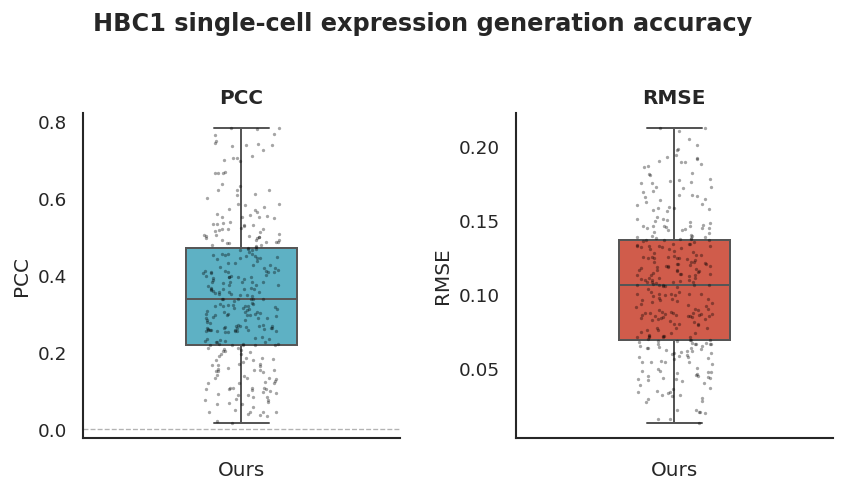

Saved figure: hbc1_pcc_rmse_boxplot.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(7.2, 4.0))
for ax, metric, color in zip(axes, ["PCC", "RMSE"], ["#4DBBD5", "#E64B35"]):
    values = metrics[metric].replace([float("inf"), float("-inf")], float("nan")).dropna()
    sns.boxplot(y=values, ax=ax, width=0.35, color=color, fliersize=0, linewidth=1.2)
    sns.stripplot(y=values, ax=ax, color="black", size=2, alpha=0.35, jitter=0.12)
    ax.set_title(metric, fontweight="bold")
    ax.set_xlabel("PhenoMap")
    ax.set_ylabel(metric)
    if metric == "PCC":
        ax.axhline(0, color="0.7", lw=0.8, ls="--")
sns.despine(fig=fig)
fig.suptitle("HBC1 single-cell expression generation accuracy", y=1.02, fontweight="bold")
fig.tight_layout()
metrics_fig = TUTORIAL_DIR / "hbc1_pcc_rmse_boxplot.png"
fig.savefig(metrics_fig, bbox_inches="tight")
plt.show()
print(f"Saved figure: {metrics_fig.name}")

## 6. Visualize marker genes

For each marker, the first column shows the spot-level expression used for weak supervision, the second column shows matched Xenium ground truth at cell level, and the third column shows PhenoMap prediction at cell level.


In [8]:
with pd.HDFStore(tutorial_data.require("hbc1.cell_features"), mode="r") as store:
    metadata = store["metadata"].copy()
metadata.index = metadata.index.astype(str)

spot_expr = pd.read_csv(tutorial_data.require("hbc1.pseudo_spots"), index_col=0)
spot_locs = pd.read_csv(tutorial_data.require("hbc1.spot_locations"))
spot_expr.index = spot_expr.index.astype(str)
spot_locs["spots"] = spot_locs["spots"].astype(str)
spot_df = spot_locs.set_index("spots").join(spot_expr, how="inner")

cell_coords = metadata.loc[pred_aligned.index, ["center_x", "center_y"]].copy()
cell_coords.columns = ["x", "y"]

available_markers = [g for g in MARKER_GENES if g in common_genes and g in spot_df.columns]
print(f"Marker genes: {available_markers}")
print(f"Spot rows: {len(spot_df):,}; cell rows: {len(cell_coords):,}")


Marker genes: ['EPCAM', 'CXCL12']
Spot rows: 4,050; cell rows: 126,438


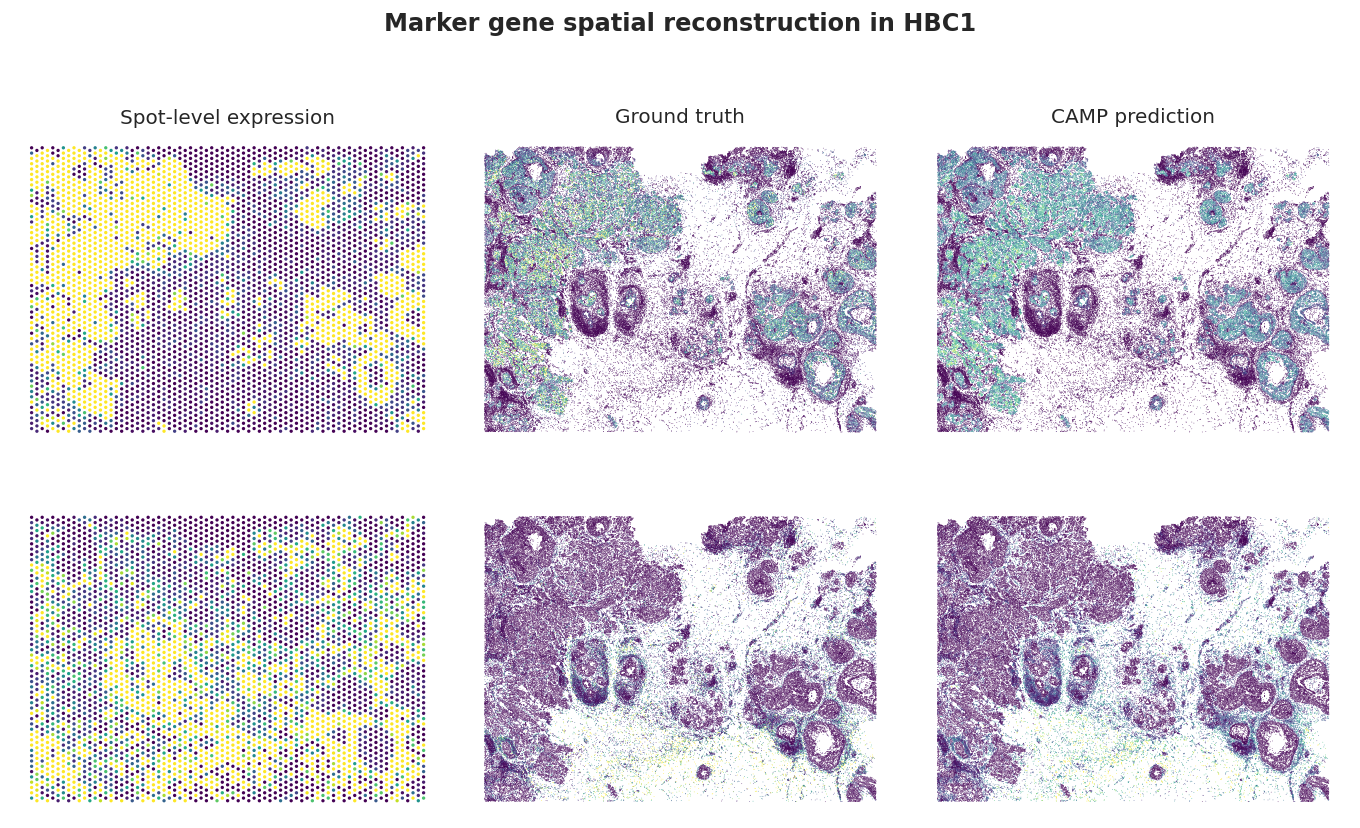

Saved figure: hbc1_marker_gene_reconstruction.png


In [9]:
marker_fig = plot_marker_gene_reconstruction(
    spot_df=spot_df,
    cell_coords=cell_coords,
    true_aligned=true_aligned,
    pred_aligned=pred_aligned,
    marker_genes=available_markers,
    output_path=TUTORIAL_DIR / "hbc1_marker_gene_reconstruction.png",
)
print(f"Saved figure: {Path(marker_fig).name}")
